In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

In [39]:
df = pd.read_csv("D:\DEV VELLY\Datasets\sales.csv")

<>:1: SyntaxWarning: invalid escape sequence '\D'
<>:1: SyntaxWarning: invalid escape sequence '\D'
C:\Users\HASEEB\AppData\Local\Temp\ipykernel_8480\3609181189.py:1: SyntaxWarning: invalid escape sequence '\D'
  df = pd.read_csv("D:\DEV VELLY\Datasets\sales.csv")


In [40]:
df.head()

,order_id,date,region,product,category,customer_type,quantity,price,discount,sales
0,1,2024-04-12,East,Laptop,Electronics,Returning,8,590,0.09,4295.20
1,2,2024-12-14,South,Monitor,Accessories,Returning,2,262,0.18,429.68
2,3,2024-09-27,North,Phone,Accessories,New,5,512,0.09,2329.60
3,4,2024-04-16,West,Mouse,Electronics,Returning,1,485,0.09,441.35
4,5,2024-03-12,West,Phone,Electronics,Returning,7,332,0.22,1812.72


In [41]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   order_id       500 non-null    int64  
 1   date           500 non-null    str    
 2   region         500 non-null    str    
 3   product        500 non-null    str    
 4   category       500 non-null    str    
 5   customer_type  500 non-null    str    
 6   quantity       500 non-null    int64  
 7   price          500 non-null    int64  
 8   discount       500 non-null    float64
 9   sales          500 non-null    float64
dtypes: float64(2), int64(3), str(5)
memory usage: 39.2 KB


In [42]:
df['date'] = pd.to_datetime(df['date'])
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   order_id       500 non-null    int64         
 1   date           500 non-null    datetime64[us]
 2   region         500 non-null    str           
 3   product        500 non-null    str           
 4   category       500 non-null    str           
 5   customer_type  500 non-null    str           
 6   quantity       500 non-null    int64         
 7   price          500 non-null    int64         
 8   discount       500 non-null    float64       
 9   sales          500 non-null    float64       
dtypes: datetime64[us](1), float64(2), int64(3), str(4)
memory usage: 39.2 KB


In [43]:
df.isnull().sum()

order_id         0
date             0
region           0
product          0
category         0
customer_type    0
quantity         0
price            0
discount         0
sales            0
dtype: int64

In [44]:
df.duplicated().sum()

np.int64(0)

<Axes: xlabel='sales', ylabel='Count'>

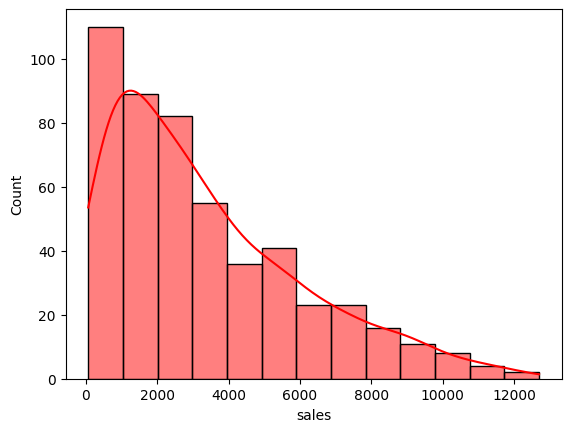

In [45]:
import seaborn as sns
sns.histplot(df['sales'], kde = True, color = "red")

<Axes: >

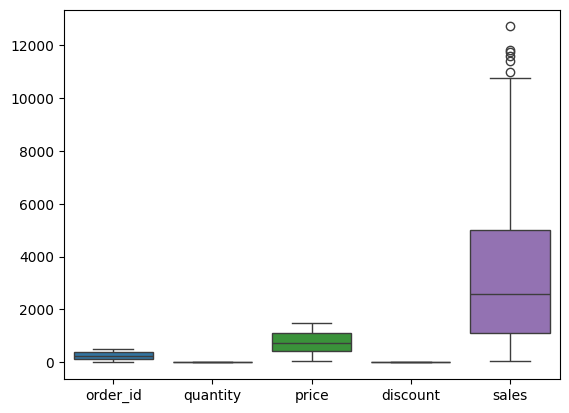

In [46]:
sns.boxplot(df)

In [47]:
df.columns

Index(['order_id', 'date', 'region', 'product', 'category', 'customer_type',
       'quantity', 'price', 'discount', 'sales'],
      dtype='str')

In [48]:
df

,order_id,date,region,product,category,customer_type,quantity,price,discount,sales
0,1,2024-04-12,East,Laptop,Electronics,Returning,8,590,0.09,4295.20
1,2,2024-12-14,South,Monitor,Accessories,Returning,2,262,0.18,429.68
2,3,2024-09-27,North,Phone,Accessories,New,5,512,0.09,2329.60
3,4,2024-04-16,West,Mouse,Electronics,Returning,1,485,0.09,441.35
4,5,2024-03-12,West,Phone,Electronics,Returning,7,332,0.22,1812.72
...,...,...,...,...,...,...,...,...,...,...
495,496,2024-11-20,South,Mouse,Accessories,Returning,6,314,0.23,1450.68
496,497,2024-01-04,North,Phone,Accessories,Returning,9,369,0.23,2557.17
497,498,2024-01-16,South,Keyboard,Electronics,Returning,6,722,0.14,3725.52
498,499,2024-10-06,North,Phone,Accessories,Returning,2,1449,0.12,2550.24


In [ ]:
df.drop(['order_id', 'date', 'discount'], axis = 1, inplace = True)

In [50]:
df

,region,product,category,customer_type,quantity,price,sales
0,East,Laptop,Electronics,Returning,8,590,4295.20
1,South,Monitor,Accessories,Returning,2,262,429.68
2,North,Phone,Accessories,New,5,512,2329.60
3,West,Mouse,Electronics,Returning,1,485,441.35
4,West,Phone,Electronics,Returning,7,332,1812.72
...,...,...,...,...,...,...,...
495,South,Mouse,Accessories,Returning,6,314,1450.68
496,North,Phone,Accessories,Returning,9,369,2557.17
497,South,Keyboard,Electronics,Returning,6,722,3725.52
498,North,Phone,Accessories,Returning,2,1449,2550.24


In [51]:
df.select_dtypes(include = ['int', 'float']).corr()

,quantity,price,sales
quantity,1.000000,0.082232,0.692406
price,0.082232,1.000000,0.668516
sales,0.692406,0.668516,1.000000


In [52]:
df.describe()

,quantity,price,sales
count,500.000000,500.000000,500.000000
mean,4.968000,768.158000,3333.059560
std,2.569081,404.010497,2693.185995
min,1.000000,50.000000,67.320000
25%,3.000000,432.750000,1120.867500
50%,5.000000,742.000000,2582.805000
75%,7.000000,1094.500000,4998.030000
max,9.000000,1499.000000,12700.800000


In [53]:
Q1 = df['sales'].quantile(0.25)
Q3 = df['sales'].quantile(0.75)
IQR = Q3 - Q1

In [54]:
Q1

np.float64(1120.8675)

In [55]:
Q3

np.float64(4998.030000000001)

In [56]:
IQR

np.float64(3877.1625000000004)

In [57]:
df.shape

(500, 7)

In [ ]:
lower_limit = Q1 - 1 * IQR
upper_limit = Q3 + 1 * IQR

df_clean = df[(df['sales'] >= lower_limit) & (df['sales'] <= upper_limit)]

print()